# Canada-U.S. Trade Shock Observatory

**Ridoy Roy | Data Analyst**

This notebook summarizes the initial release using validated, processed U.S. Census data. It focuses on the aggregate change, tariff timing, and the HS6 products contributing most to the 2025 decline.

## 1. Load the validated release data

The pipeline itself uses only the Python standard library. This notebook uses pandas and matplotlib for concise exploration and presentation.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

monthly = pd.read_csv(ROOT / 'data/processed/core_steel_monthly_summary.csv')
drivers = pd.read_csv(ROOT / 'data/processed/top_10_hs6_decline_contributors.csv', dtype={'hs6': str})
validation = json.loads((ROOT / 'data/processed/release_validation_report.json').read_text())
assert validation['status'] == 'passed'
monthly['period_start'] = pd.to_datetime(monthly['period_start'])
monthly.shape, validation

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\ridoy\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


((24, 18),
 {'status': 'passed',
  'errors': [],
  'panel_rows': 3694,
  'months': 24,
  'hs6_codes': 164,
  'country_code': '1220',
  'scope': 'section232_core_steel',
  'transition_months': ['2025-03', '2025-06'],
  'hs6_quantity_available': False,
  'raw_snapshot_count': 96,
  'product_universe_hts10_count': 746,
  'product_universe_hs6_count': 168})

## 2. Compare annual import value and calculated duty

In [2]:
annual = (monthly.assign(year=monthly['period_start'].dt.year)
          .groupby('year', as_index=False)[['import_value_usd', 'calculated_duty_usd']].sum())
annual['import_value_change_pct'] = annual['import_value_usd'].pct_change() * 100
annual_display = annual.copy()
annual_display['import_value_usd'] = annual_display['import_value_usd'].map('${:,.0f}'.format)
annual_display['calculated_duty_usd'] = annual_display['calculated_duty_usd'].map('${:,.0f}'.format)
annual_display['import_value_change_pct'] = annual_display['import_value_change_pct'].map(lambda value: '' if pd.isna(value) else f'{value:+.1f}%')
annual_display

,year,import_value_usd,calculated_duty_usd,import_value_change_pct
0,2024,"$7,134,857,615",$0,
1,2025,"$4,506,162,362","$1,070,086,289",-36.8%


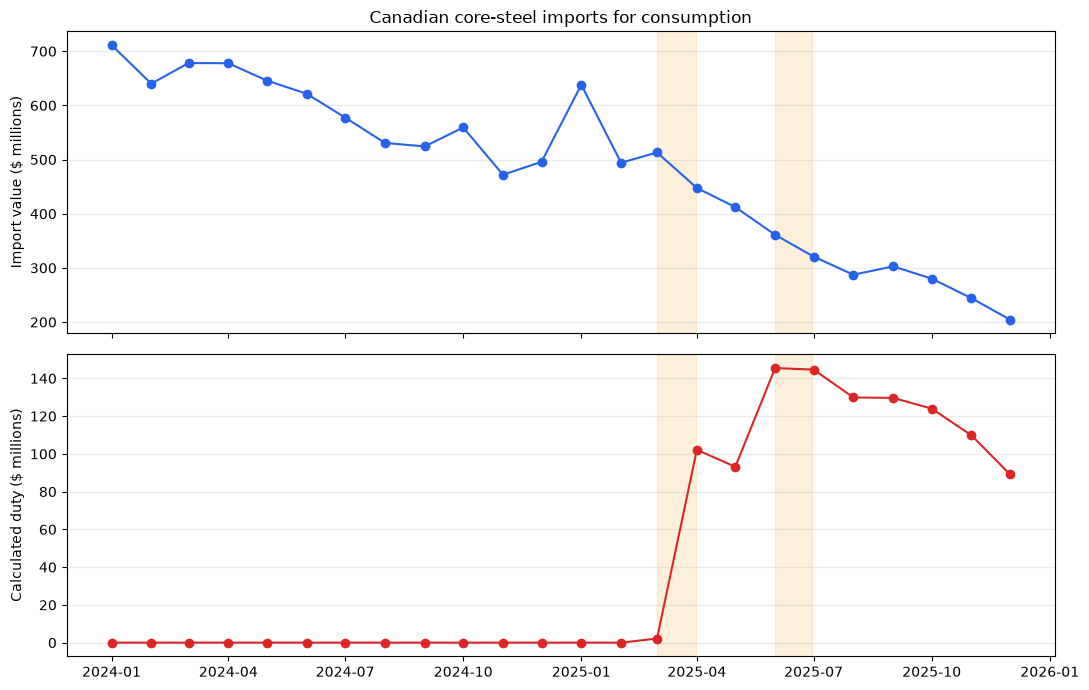

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(monthly['period_start'], monthly['import_value_usd'] / 1e6, marker='o', color='#2563eb')
axes[0].set_ylabel('Import value ($ millions)')
axes[0].set_title('Canadian core-steel imports for consumption')
axes[1].plot(monthly['period_start'], monthly['calculated_duty_usd'] / 1e6, marker='o', color='#dc2626')
axes[1].set_ylabel('Calculated duty ($ millions)')
for ax in axes:
    ax.axvspan(pd.Timestamp('2025-03-01'), pd.Timestamp('2025-03-31'), color='#f59e0b', alpha=.15)
    ax.axvspan(pd.Timestamp('2025-06-01'), pd.Timestamp('2025-06-30'), color='#f59e0b', alpha=.15)
    ax.grid(axis='y', alpha=.25)
plt.tight_layout()

## 3. Identify the products contributing most to the decline

Contribution is an accounting decomposition of the annual value change. It is not a causal estimate.

In [4]:
display_cols = ['rank', 'hs6', 'base_year_value_usd', 'current_year_value_usd', 'change_usd', 'share_of_total_decline_pct']
drivers_display = drivers[display_cols].copy()
for column in ['base_year_value_usd', 'current_year_value_usd', 'change_usd']:
    drivers_display[column] = drivers_display[column].map('${:,.0f}'.format)
drivers_display['share_of_total_decline_pct'] = drivers_display['share_of_total_decline_pct'].map('{:.1f}%'.format)
drivers_display

,rank,hs6,base_year_value_usd,current_year_value_usd,change_usd,share_of_total_decline_pct
0,1,721049,"$817,275,018","$536,570,556","$-280,704,462",10.7%
1,2,730661,"$447,899,317","$235,107,810","$-212,791,507",8.1%
2,3,720837,"$241,700,626","$115,346,809","$-126,353,817",4.8%
3,4,722530,"$233,167,321","$107,989,534","$-125,177,787",4.8%
4,5,720838,"$222,897,410","$107,924,060","$-114,973,350",4.4%
5,6,720917,"$214,103,254","$114,499,608","$-99,603,646",3.8%
6,7,721391,"$300,473,574","$201,197,321","$-99,276,253",3.8%
7,8,720839,"$181,406,980","$85,297,457","$-96,109,523",3.7%
8,9,720916,"$219,426,085","$124,338,041","$-95,088,044",3.6%
9,10,720712,"$171,668,068","$80,909,142","$-90,758,926",3.5%


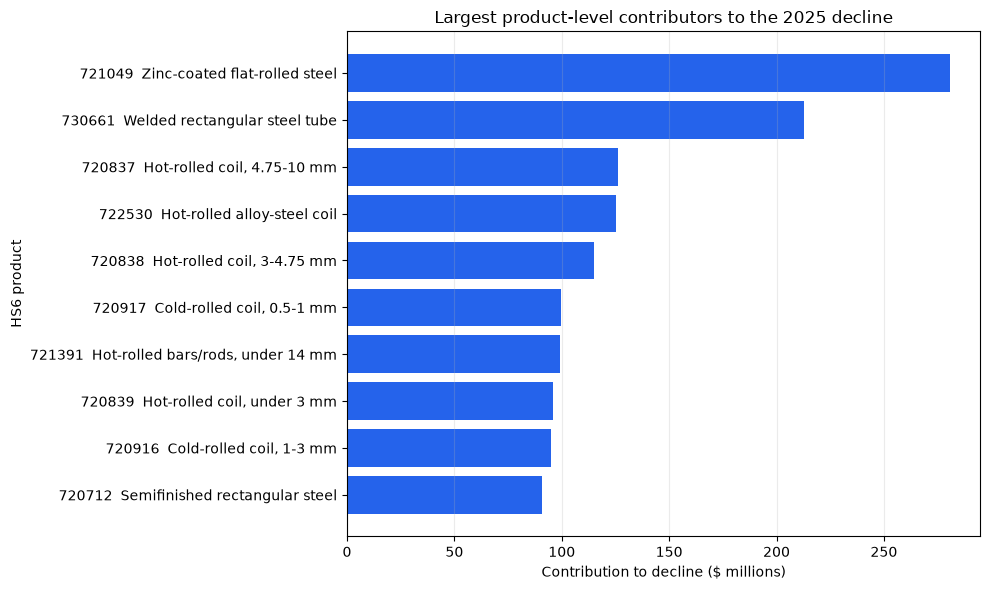

In [5]:
plot_data = drivers.sort_values('change_usd', ascending=False).copy()
plot_data['product_label'] = plot_data['hs6'] + '  ' + plot_data['product_name']
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data['product_label'], -plot_data['change_usd'] / 1e6, color='#2563eb')
ax.set_xlabel('Contribution to decline ($ millions)')
ax.set_ylabel('HS6 product')
ax.set_title('Largest product-level contributors to the 2025 decline')
ax.grid(axis='x', alpha=.25)
plt.tight_layout()

## 4. Conclusion

Import value in the defined core-steel scope was 36.8% lower in 2025 than in 2024. Zinc-coated flat-rolled steel (HS6 721049) and welded rectangular steel tube (HS6 730661) made the largest individual contributions to the decline. Calculated duty rose after the policy changes, but the descriptive design cannot isolate the tariff from prices, demand, seasonality, inventory timing, or substitution.